In [27]:
import pandas as pd
import os as os

In [28]:
os.chdir("/PMIDPMConly_lists")

In [56]:
PMIDs = pd.read_csv("pmids_2024-04-11.txt", sep='\t', header=None)[0].tolist()
PMCIDs = pd.read_csv("pmidsPMC_2024-05-16.txt", sep='\t', header=None)[0].tolist()

In [30]:
print (PMCIDs)

               0
0       19722279
1       15956611
2       31002071
3       29554271
4       19651770
...          ...
234656  22338125
234657  28342889
234658  18515401
234659  18400854
234660  34999731

[234661 rows x 1 columns]


In [59]:
pie.columns = ['PMID', 'PMCID']
print(pie)

            PMID       PMCID
0       17543862  19722279.0
1       35907859  15956611.0
2       19024597  31002071.0
3       29087340  29554271.0
4       28357617  19651770.0
...          ...         ...
498958  19445949         NaN
498959  21906700         NaN
498960  25159149         NaN
498961  34733796         NaN
498962  20364833         NaN

[498963 rows x 2 columns]


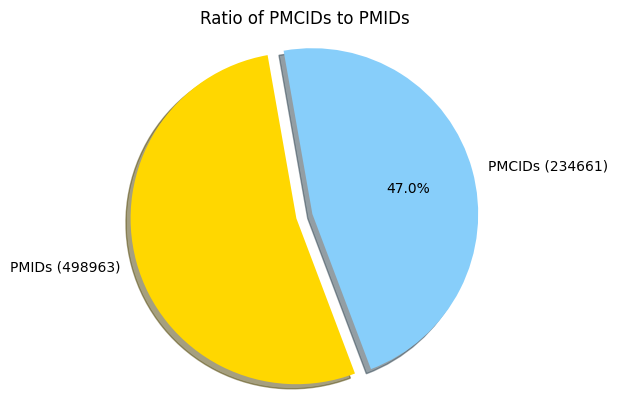

In [60]:
import matplotlib.pyplot as plt

# Count the number of PMIDs and PMCIDs
pmid_count = len(pie['PMID'])
pmcid_count = pie['PMCID'].count()

# Calculate the percentage of PMCIDs
pmcid_percentage = (pmcid_count / pmid_count) * 100

# Create a pie chart
labels = [f'PMIDs ({pmid_count})', f'PMCIDs ({pmcid_count})']
sizes = [100 - pmcid_percentage, pmcid_percentage]
colors = ['gold', 'lightskyblue']
explode = (0.1, 0)  # explode 1st slice

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct=lambda p : '{:.1f}%'.format(p) if p < 50 else '',
        shadow=True, startangle=100, colors=colors)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Ratio of PMCIDs to PMIDs')
plt.show()

In [61]:
avbl_full_text_database = pd.read_csv("avbl_full_text_ oa_database.csv", sep=',', header=0)

In [62]:
avbl_full_text = avbl_full_text_database['Accession ID']
print(len(avbl_full_text))


121664


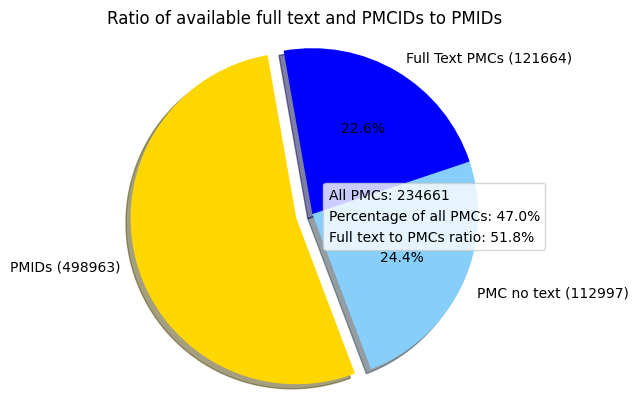

In [87]:
import matplotlib.pyplot as plt

# Count the number of PMIDs and PMCIDs
pmid_count = len(pie['PMID'])
pmcid_count = pie['PMCID'].count()
full_text_count = len(avbl_full_text)

# Calculate the percentage of PMCIDs, full text to PMIDs ratio, and full text to PMCIDs ratio
pmcid_percentage = (pmcid_count / pmid_count) * 100
full_text_percentage_pmid = (full_text_count / pmid_count) * 100
full_text_percentage_pmc = (pmcid_percentage - full_text_percentage_pmid)
full_text_percentage_pmcid = (full_text_count / pmcid_count) * 100

# Create a pie chart
labels = [f'PMIDs ({pmid_count})', f'PMC no text ({pmcid_count - full_text_count})', f'Full Text PMCs ({full_text_count})']
sizes = [100 - pmcid_percentage , pmcid_percentage - full_text_percentage_pmc, full_text_percentage_pmc]
colors = ['gold', 'lightskyblue', 'blue']
explode = (0.1, 0, 0)  # explode 1st slice

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct=lambda p : '{:.1f}%'.format(p) if p < 50 else '',
        shadow=True, startangle=100, colors=colors)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Custom legend without color swatches, here I added items regardless of order in legend
pmcid_count_str = f'All PMCs: {pmcid_count}'
pmcid_percentage_str = f'Percentage of all PMCs: {pmcid_percentage:.1f}%'
full_text_to_PMCs_str = f'Full text to PMCs ratio: {full_text_percentage_pmcid:.1f}%'
ax1.legend([pmcid_count_str, pmcid_percentage_str, full_text_to_PMCs_str], loc='right', handletextpad=0, handlelength=0)

plt.title('Ratio of available full text and PMCIDs to PMIDs')
plt.show()